### __1. Importando librerías__
---

In [22]:
#IMPORTANTE LIBRERÍAS RELEVANTES
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

#OTRAS CONFIGURACIONES: EN GENERAL, EN BLOQUE DE IMPORTS, SUELE EXISTIR UN ESPACIO DONDE SE HACEN DEFINICIONES GENERALES
#                       COMO ELIMINAR CIERTOS "WARNINGS" MOLESTOS, QUITAR LÍMITES DE PANDAS SOBRE CUANTAS FILAS O COLUMNAS
#                       MUESTRA AL MOMENTO DE IMPIRMIR EL DATAFRAME, DEFINIR ESTILOS PRE-DEFINIDOS PARA GRÁFICOS, ETC.

import warnings                                                  #MANEJO DE WARNINGS - ADVERTENCIAS
warnings.simplefilter(action='ignore', category = FutureWarning) #QUITAR WARNINGS MOLESTOS
pd.set_option('display.max_columns', None)                       #ELIMINA LIMITES DE PANDAS PARA MOSTRAR COLUMNAS
pd.set_option('display.max_rows', None)                          #ELIMINA LIMITES DE PANDAS PARA MOSTRAR FILAS
pd.set_option('display.max_colwidth', None)                      #AUTOAJUSTA ANCHO DE COLUMNAS
pd.set_option('display.float_format', lambda x: '%.3f' % x)      #PERMITE EVADIR EL MOSTRAR NÚMEROS CON NOTACIÓN CINETÍFICA
plt.rcParams['figure.dpi'] = 140                                 #NIVEL DE RESOLUCIÓN.

### __2. Leyendo datasets__
---

In [2]:
#RUTAS TABLAS: UBICACIONES DE LAS TABLAS EN REPOSITORIO DE GITHUB.
df_1_path = "https://media.githubusercontent.com/media/hector1994/e_commerce_funnel_data_generator/refs/heads/master/df_adicional_2.csv"
df_2_path = "https://media.githubusercontent.com/media/hector1994/e_commerce_funnel_data_generator/refs/heads/master/sales_data_dirty_sp7_data.csv"

#UTILIZAREMOS EL DATAFRAME PARA UN DETERMINADO TIPO DE ANÁLISIS.
df_numerical_analysis    = pd.read_csv(df_1_path)
df_categorical_analysis  = pd.read_csv(df_2_path)

### __3. Analizando variables numéricas__

In [27]:
#EXPLOREMOS EL DATASET. CREMEMOS JUNTOS UNA FUNCIÓN QUE PERMITA ANALIZAR UN DATAFRAME UTILIZANDO LAS TÍPICOS
#                       MÉTODOS DE EXPLORACIÓN INICIAL (head, info, describe)

def dataframe_summary(data,show_nrows):
  print("EXPLORACIÓN INICIAL DEL DATAFRAME:")
  print("-----------------------------------")

  nrows = data.shape[0]  #CALCULANDO EL NÚMERO DE FILAS.
  ncols = data.shape[1]  #CALCULANDO EL NÚMERO DE COLUMNAS.

  print(f"- Número de registros: {nrows}")
  print(f"- Número de columnas : {ncols}")

  print("-----------------------------------")
  print(f"- PRIMEROS {show_nrows} REGISTROS DEL DATAFRAME:")
  display(data.head(show_nrows))

  print("\n")

  print("- MÉTODO INFO:")
  display(data.info())

  print("\n")

  print("- MÉTODO DESCRIBE:")
  display(data.describe())


In [30]:
dataframe_summary(data = df_numerical_analysis, show_nrows = 7)

EXPLORACIÓN INICIAL DEL DATAFRAME:
-----------------------------------
- Número de registros: 1000
- Número de columnas : 3
-----------------------------------
- PRIMEROS 7 REGISTROS DEL DATAFRAME:


,Equipo_Alfa,Equipo_Beta,Equipo_Gamma
0,3052.096,3290.556,3938.691
1,3144.268,2228.425,5897.391
2,3187.983,3529.214,5409.313
3,2637.979,1834.660,5555.498
4,3089.254,2750.116,5707.768
5,3438.835,3551.508,4346.452
6,2941.353,2926.988,4693.726




- MÉTODO INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Equipo_Alfa   1000 non-null   float64
 1   Equipo_Beta   1000 non-null   float64
 2   Equipo_Gamma  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


None



- MÉTODO DESCRIBE:


,Equipo_Alfa,Equipo_Beta,Equipo_Gamma
count,1000.000,1000.000,1000.000
mean,3004.833,2906.426,5139.638
std,244.804,737.420,739.033
min,2189.683,1775.857,-2045.804
25%,2838.102,2386.212,4830.072
50%,3006.325,2738.450,5300.150
75%,3161.986,3227.652,5632.099
max,3963.183,7423.191,6234.843


In [31]:
#DEFINAMOS UNA FUNCIÓN QUE PERMITA CALCULAR TODA LA ESTADÍSTICA DESCRIPTIVA BÁSICA PARA LAS COLUMNAS NUMÉRICAS.

def statistic_numerical_variables(data,num_column_list):

  print("RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS:")
  print("-----------------------------------")

  for column in num_column_list:

    min     = data[column].min()
    max     = data[column].max()
    range   = (data[column].max() - data[column].min())
    mean    = data[column].mean()
    median  = data[column].median()
    std     = data[column].std()
    Q1      = data[column].quantile(0.25)
    Q2      = data[column].quantile(0.50)
    Q3      = data[column].quantile(0.75)

    print(f"REPORTE COLUMNA: {column}")
    print(f"- min              : {min}")
    print(f"- max              : {max}")
    print(f"- range            : {range}")
    print(f"- mean             : {mean}")
    print(f"- median           : {median}")
    print(f"- standar deviation: {std}")
    print(f"- Q1 (25%)         : {Q1}")
    print(f"- Q2 (50%)         : {Q2}")
    print(f"- Q3 (75%)         : {Q3}")
    print(f"-----------------------------------")

In [32]:
columns_numeric = ['Equipo_Alfa','Equipo_Beta','Equipo_Gamma']

statistic_numerical_variables(data = df_numerical_analysis, num_column_list = columns_numeric)

RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS:
-----------------------------------
REPORTE COLUMNA: Equipo_Alfa
- min              : 2189.683164982732
- max              : 3963.18287266368
- range            : 1773.4997076809482
- mean             : 3004.833013955581
- median           : 3006.325153058722
- standar deviation: 244.8039845449189
- Q1 (25%)         : 2838.102423634412
- Q2 (50%)         : 3006.325153058722
- Q3 (75%)         : 3161.9859688682327
-----------------------------------
REPORTE COLUMNA: Equipo_Beta
- min              : 1775.8569732245692
- max              : 7423.191099328625
- range            : 5647.334126104055
- mean             : 2906.4264471801985
- median           : 2738.449714280895
- standar deviation: 737.4203808957285
- Q1 (25%)         : 2386.211907537572
- Q2 (50%)         : 2738.449714280895
- Q3 (75%)         : 3227.6519529263487
-----------------------------------
REPORTE COLUMNA: Equipo_Gamma
- min              : -2045.804066311888
- max         

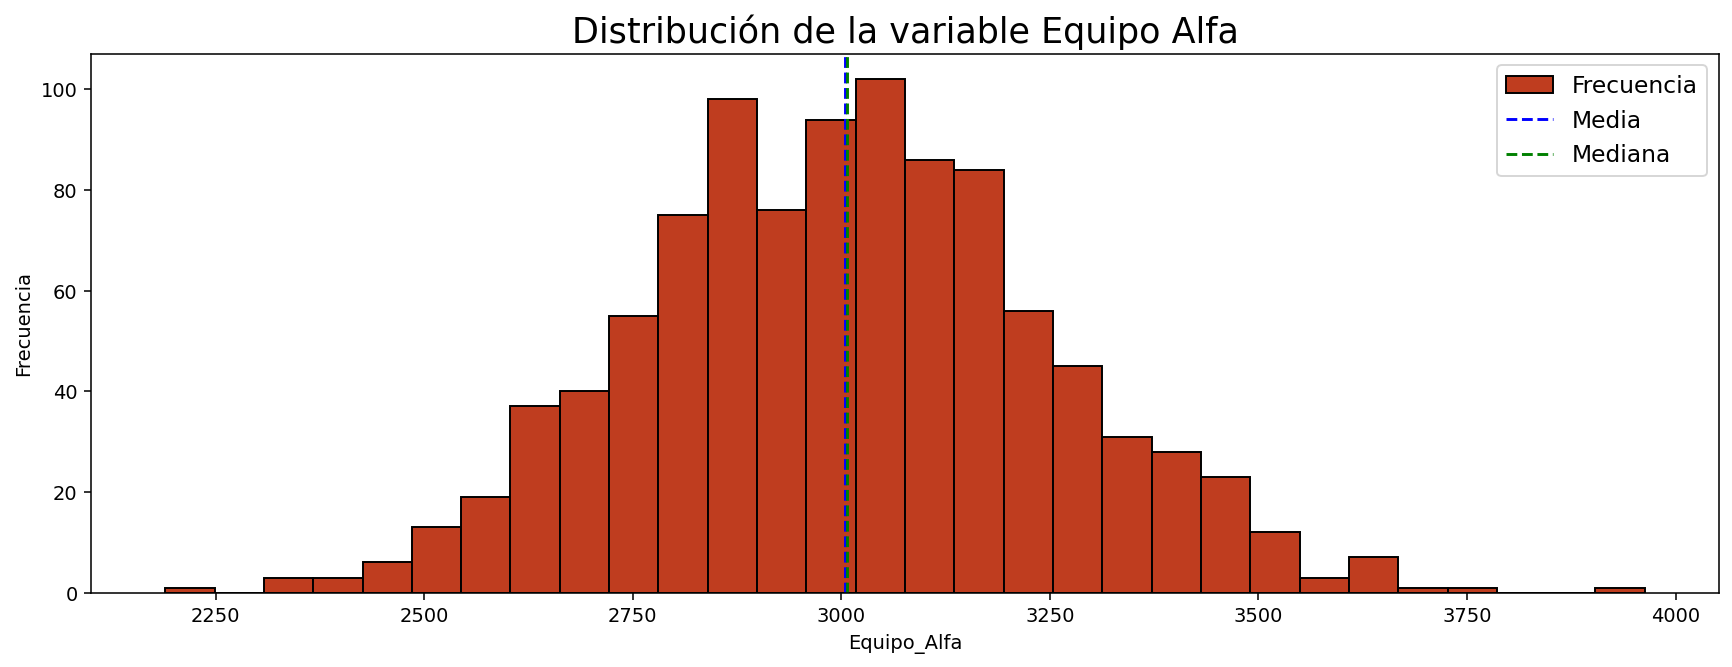

In [35]:
#GRAFIQUEMOS LA DISTRIBUCIÓN DE LOS DATOS: HISTOGRAMA - MATPLOTLIB

plt.figure(figsize = (15,5))  #DEFINIR DIMENSIONES DEL PLOT ANCHO - ALTO.

plt.hist(data      = df_numerical_analysis,
         x         = 'Equipo_Alfa',
         bins      = 30,
         color     = '#BF3D1F',
         edgecolor = 'black',
         label     = "Frecuencia")

plt.title('Distribución de la variable Equipo Alfa', fontsize = 18)

plt.axvline(df_numerical_analysis['Equipo_Alfa'].mean()  , color = 'blue', linestyle = "--",  label = "Media")
plt.axvline(df_numerical_analysis['Equipo_Alfa'].median(), color = 'green', linestyle = "--", label = 'Mediana')

plt.xlabel('Equipo_Alfa')
plt.ylabel('Frecuencia')

plt.legend(fontsize = 12)
plt.show()

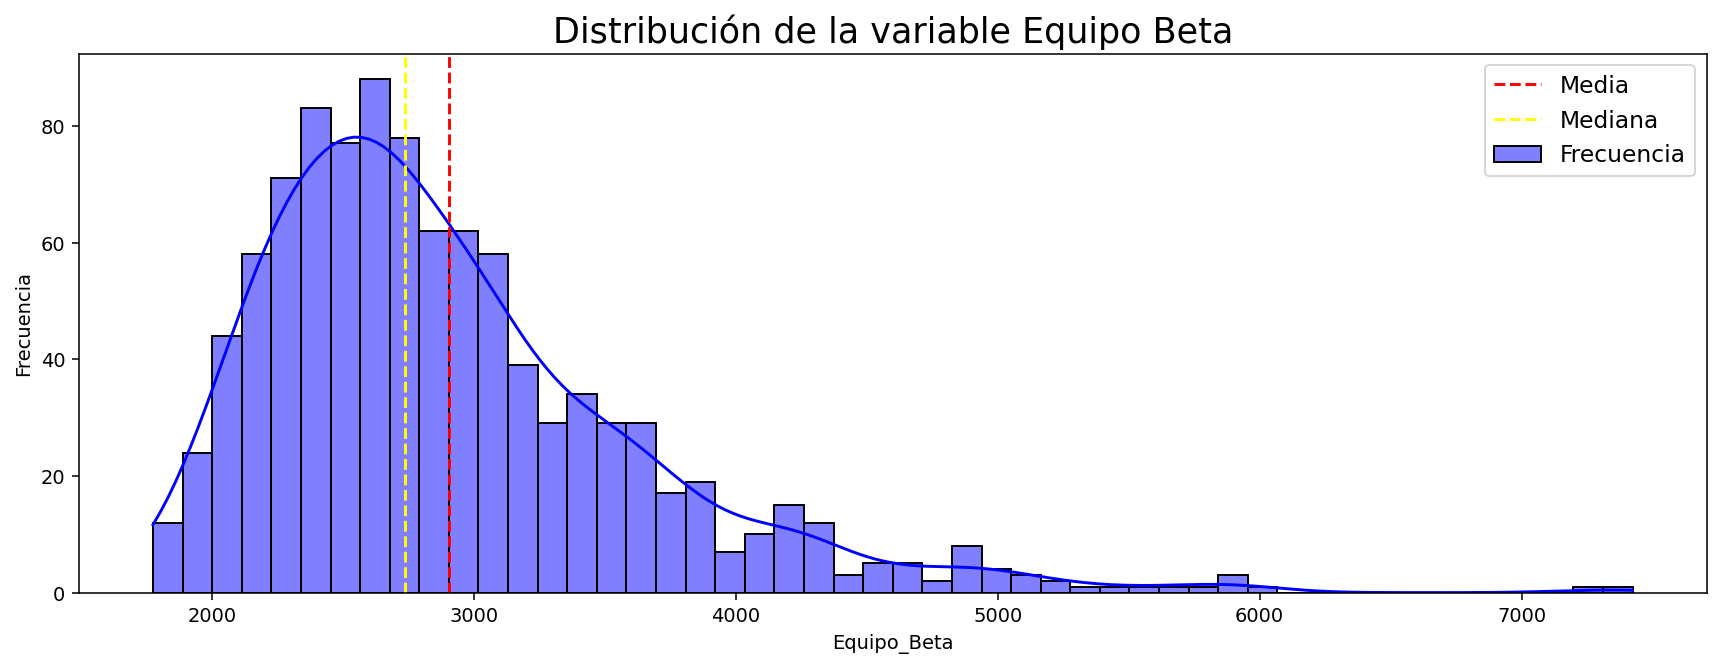

In [36]:
#GRAFIQUEMOS LA DISTRIBUCIÓN DE LOS DATOS: HISTOGRAMA - SEABORN
plt.figure(figsize = (15,5))

sns.histplot(data = df_numerical_analysis,
             x = 'Equipo_Beta',
             bins = 50,
             color = 'blue',
             edgecolor = 'black',
             label ="Frecuencia",
             kde =  True)

plt.title('Distribución de la variable Equipo Beta', fontsize = 18)

plt.axvline(x = df_numerical_analysis['Equipo_Beta'].mean(), color = 'red', linestyle = "--", label = 'Media')
plt.axvline(x = df_numerical_analysis['Equipo_Beta'].median(), color = 'yellow', linestyle = "--", label = 'Mediana')

plt.xlabel('Equipo_Beta')
plt.ylabel('Frecuencia')

plt.legend(fontsize = 12)

plt.show()

In [37]:
#CREEMOS CON UNA FUNCIÓN GRAFIQUE EL HISTOGRAMA PARA CADA CAMPO.
def hist_ploting(data, num_column_list):

  for column in num_column_list:
    plt.figure(figsize = (15,5))

    sns.histplot(data = df_numerical_analysis,
                 x = column,
                 bins = 50,
                 color = 'green',
                 edgecolor = 'black',
                 label ="Frecuencia",
                 kde =  True)

    plt.title(f'Distribución de la variable {column}', fontsize = 18)
    plt.xlabel(f"{column} [$]")
    plt.ylabel("Frecuencia")

    plt.axvline(df_numerical_analysis[column].mean(), color = 'red', linestyle = "--", label = 'Media')
    plt.axvline(df_numerical_analysis[column].median(), color = 'blue', linestyle = "--", label = 'Mediana')

    plt.legend(fontsize = 12)
    plt.show()

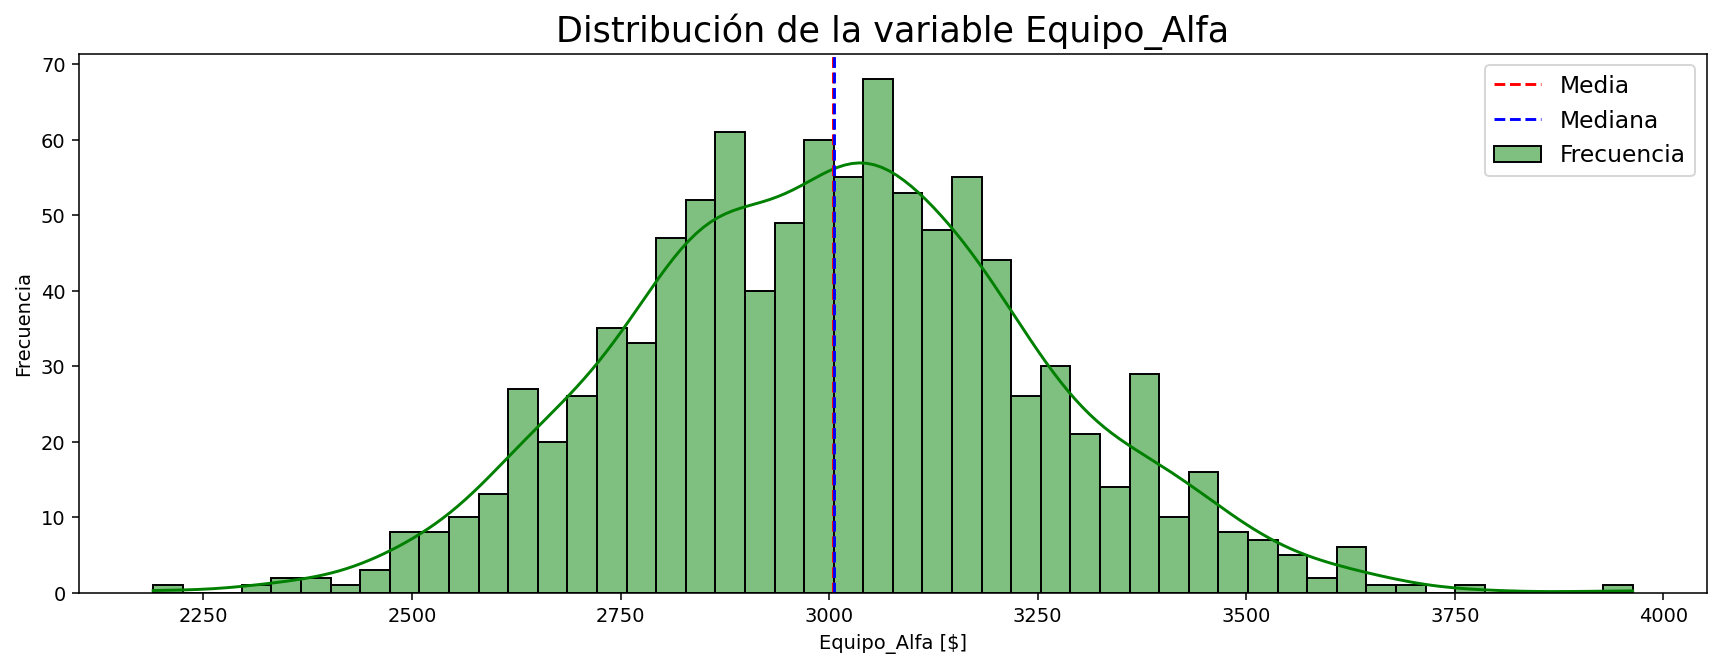

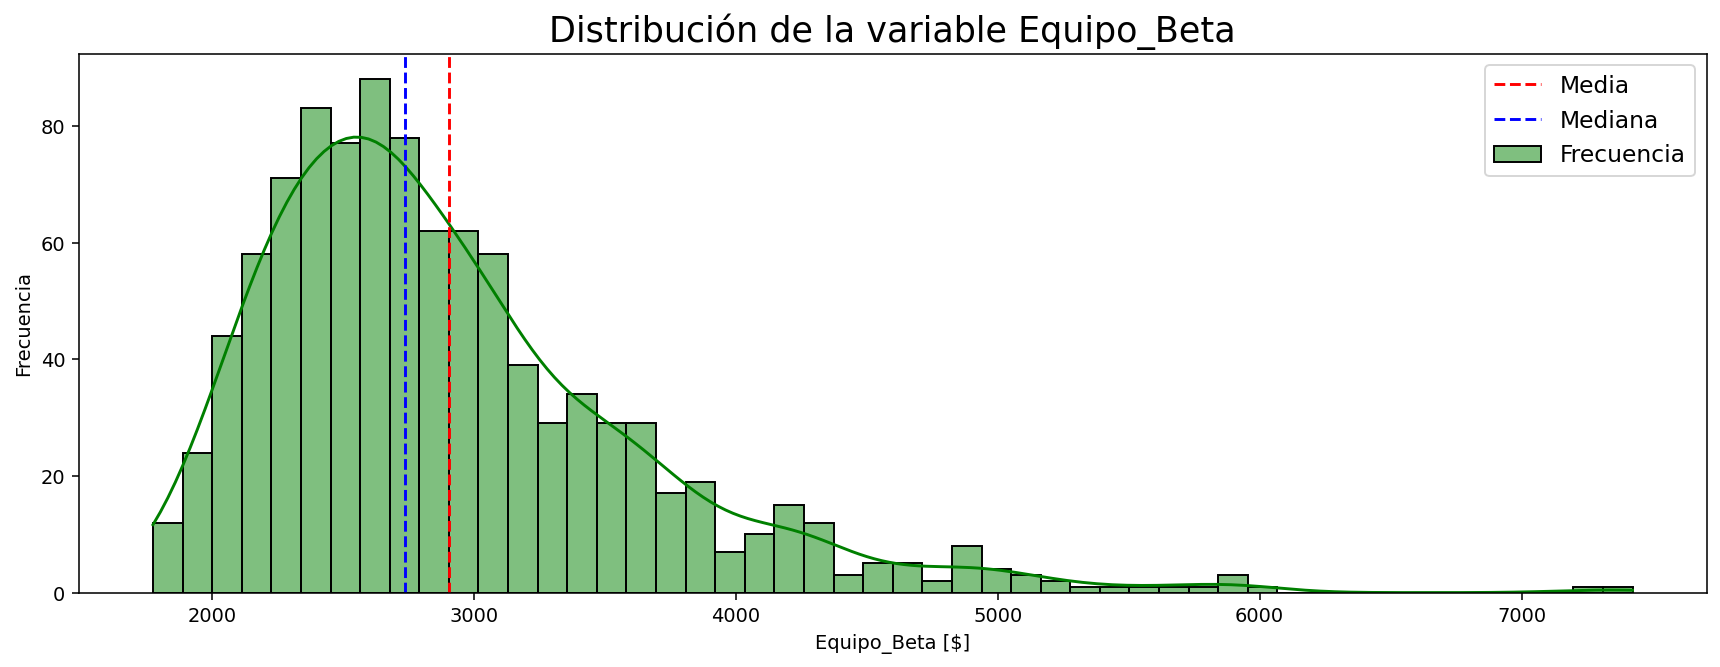

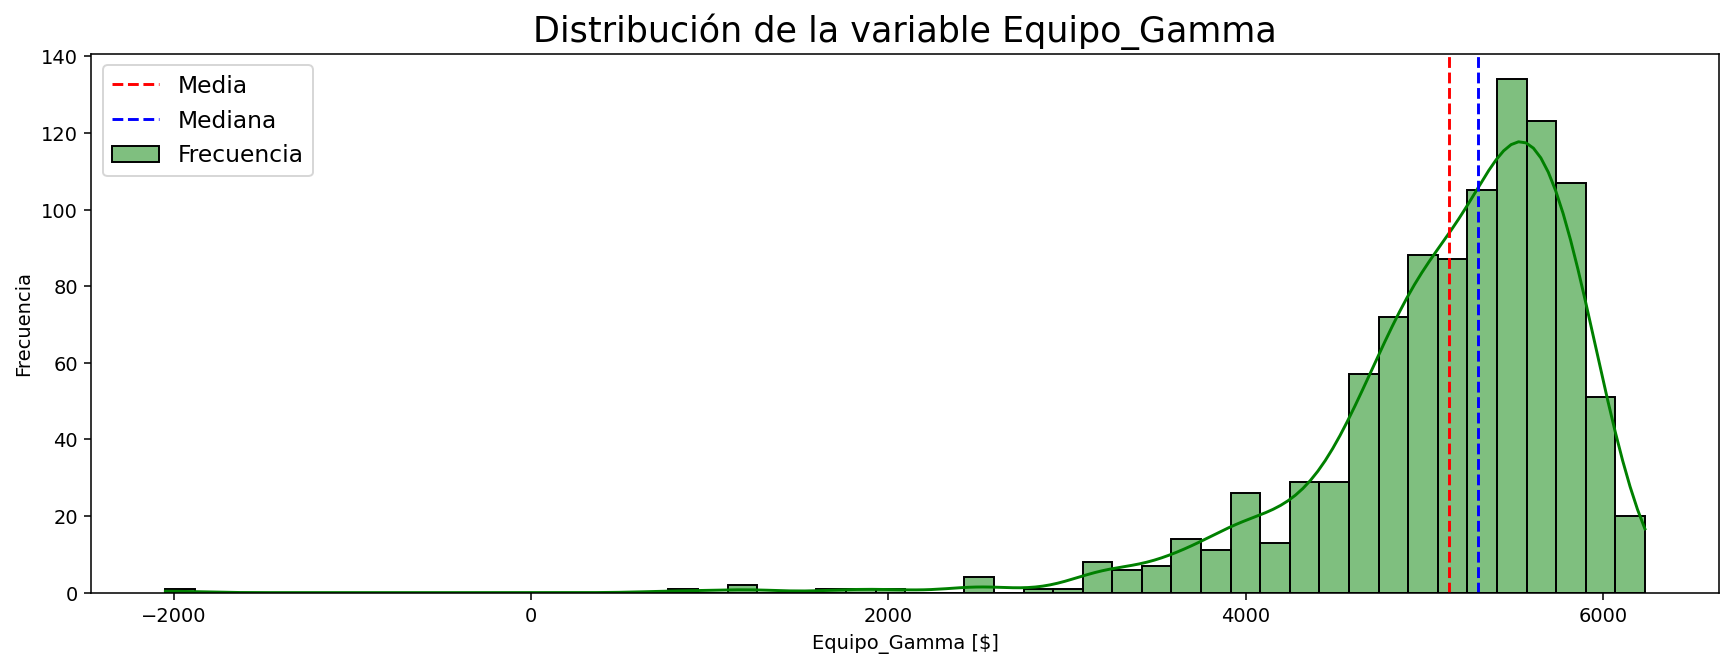

In [38]:
hist_ploting(data = df_numerical_analysis, num_column_list = columns_numeric)

### __4. Analizando variables categóricas__
---

In [10]:
#EXPLOREMOS EL DATASET
df_categorical_analysis.head()

,order_id,order_date,customer_id,customer_name,customer_email,customer_country,country_code,customer_city,customer_address,product_id,product_name,product_category,quantity,price_per_unit,total_weight,shipping_cost,total_amount_gross,discount_amount,tax_amount,final_total_amount,payment_method,shipping_status
0,98c01d39-0be7-4ee0-9ecf-50a50b63159a,2024-06-12,250414,Jorge Pérez,jorge.pérez_250414@example.com,Chile,CHL,Rancagua,5054 Calle Los Pinos,P012,Headphones NoiseCancelling,Electronics,1,250.000,0.300,5.450,250.000,0.000,47.500,302.950,PayPal,Delivered
1,715759ca-06c2-4b36-b86f-177b6b154a7a,2025-05-29,269884,Isabel Castro,isabel.castro_269884@example.com,Colombia,COL,Medellín,5375 Calle Los Alamos,P015,Hair Dryer,Home,1,35.000,0.600,5.900,35.000,3.500,5.985,43.385,Credit Card,Shipped
2,46e91d25-94ff-4eca-9fe7-7d7cb4683429,2025-10-04,54582,Francisco Rojas,francisco.rojas_54582@example.com,Argentina,ARG,Mar del Plata,3777 Calle Los Pinos,P008,Office Chair,Furniture,1,200.000,15.000,27.500,200.000,10.000,36.100,253.600,PayPal,Shipped
3,df2478f3-f34f-4f18-82eb-86727241b153,2024-11-19,194401,Carlos Ramírez,carlos.ramírez_194401@example.com,Perú,PER,Piura,2115 Calle Secundaria,P015,Hair Dryer,Home,1,NaN,0.600,5.900,35.000,0.000,6.650,47.550,PayPal,Delivered
4,e6a850d8-d658-46fb-9c94-4f99af54a596,2026-01-07,104597,Pedro García,pedro.garcía_104597@example.com,Argentina,ARG,Córdoba,6181 Calle Secundaria,P002,Smartphone X,Electronics,1,800.000,0.200,5.300,800.000,40.000,144.400,909.700,Bank Transfer,Delivered


In [11]:
#DEFINAMOS UNA LISTA CON COLUMNAS CATEGÓRICA PARA ANALIZAR + USEMOS DESCRIBE PARA COLUMNAS CATEGÓRICAS.
columns_categorical = ["payment_method", "shipping_status", "product_category", "customer_country"]
df_categorical_analysis[columns_categorical].describe()

,payment_method,shipping_status,product_category,customer_country
count,2001000,1800888,2001000,2001000
unique,12,4,5,8
top,Credit Card,Delivered,Electronics,Brasil
freq,812021,721743,587853,803728


In [40]:
#USEMOS VALUE COUNTS PARA HACER UN CONTEO PARA LOS VALORES DE UNA VARIABLE CATEGÓRICA.
100*df_categorical_analysis["customer_country"].value_counts(normalize = True)

,proportion
customer_country,
Brasil,40.166
México,24.901
Colombia,9.972
Argentina,8.897
Perú,7.028
Chile,3.978
Ecuador,3.034
Uruguay,2.024


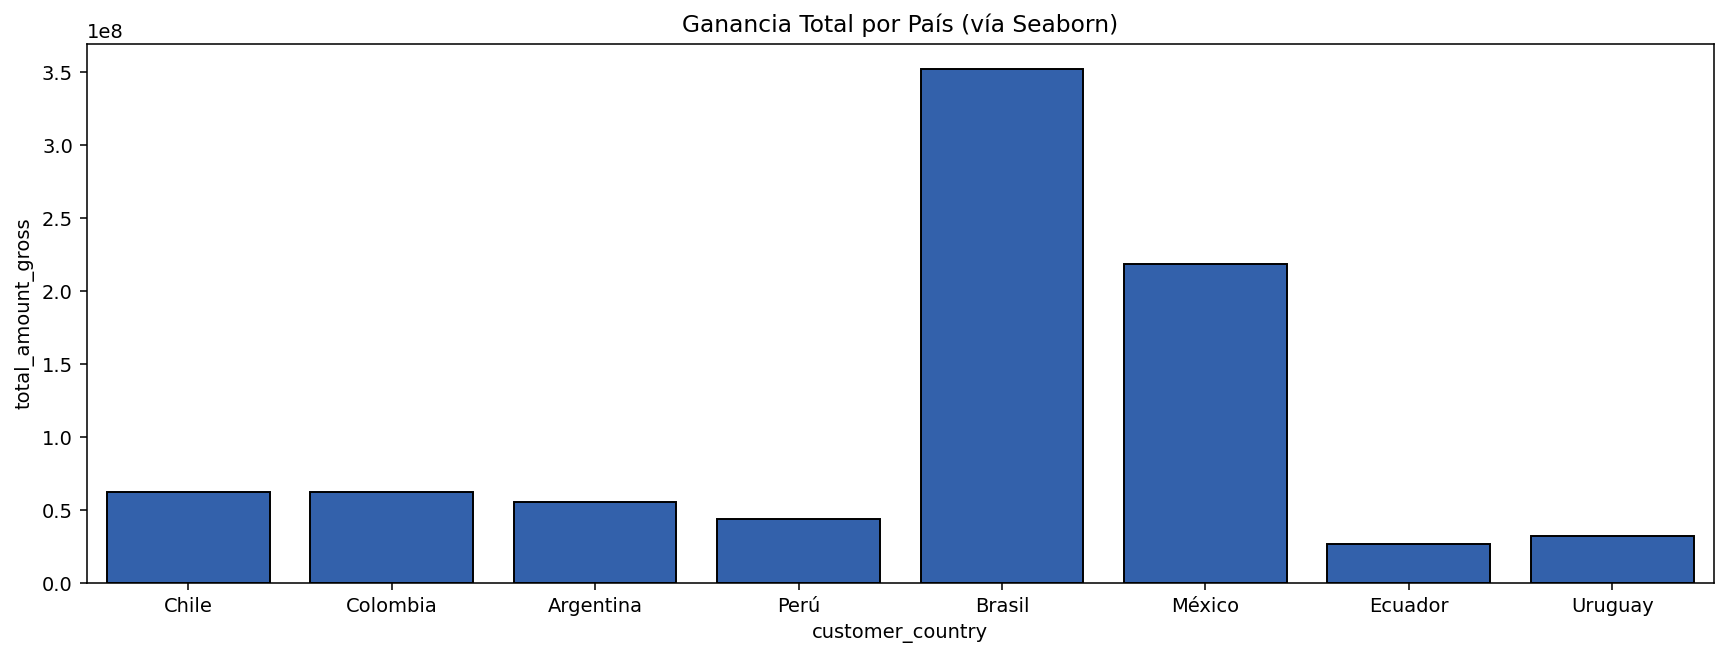

In [13]:
#CONSTRUYAMOS UN BARPLOT
plt.figure(figsize = (15,5))

sns.barplot(
    data = df_categorical_analysis,
    x = "customer_country",
    y = "total_amount_gross",
    estimator = "sum",
    color = '#1F5CBF',
    edgecolor = 'black',
    errorbar = None
)

# Estética final rápida
plt.title("Ganancia Total por País (vía Seaborn)")
plt.show()

### __4. BOX PLOT. Detectando valores nulos__

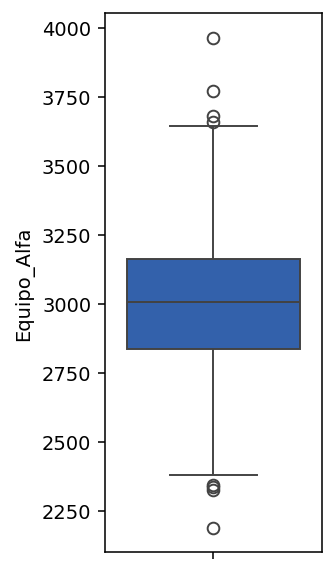

In [14]:
#CONSTRUYAMOS UN BOXPLOT PARA DETECTAR LOS VALORES ATÍPICOS.
plt.figure(figsize = (2,5))
sns.boxplot(data = df_numerical_analysis, y = 'Equipo_Alfa', color = '#1F5CBF')
plt.show()